# Multiclass IMV — Car Evaluation

One-vs-rest IMV and the pairwise IMV matrix on the UCI Car Evaluation dataset
(four classes: unacc, acc, good, vgood).

This dataset has **no counterpart in the original notebooks** — the published
figure's Car Evaluation panel was a hardcoded literal whose generating code was
never preserved. These are therefore new results, not a replication.

The `good`/`vgood` pair holds only 134 of 1728 rows, so that cell of the matrix is
the least stable; treat it with the seed spread in view.

**Pipeline**: download from UCI → ordinal-encode → 10 seeds × 3 estimators →
aggregate.

Full documentation: `documentation/examples/multi_imv/car_evaluation.md`.

In [1]:
import os, sys, tempfile, warnings, itertools
from pathlib import Path

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# No dataset is stored in this repository. Everything downloads on demand into a
# user-level cache outside the working tree.
CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
CACHE.mkdir(parents=True, exist_ok=True)

ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "multi_imv_car_evaluation"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "requirements.txt").is_file() and (path / "src").is_dir()),
    Path.cwd(),
)
FIGURES = Path(os.environ.get(
    "IMV_FIGURE_DIR", PROJECT_ROOT / "output" / "figures"
))
FIGURES.mkdir(parents=True, exist_ok=True)
FORCE_RECOMPUTE = os.environ.get("IMV_FORCE_RECOMPUTE", "0").strip().lower() in {
    "1", "true", "yes",
}

# Ten seeds, as required for any reported IMV result. The seed drives the fold
# split and the estimator, so every number below is a mean over ten independent
# fold partitions.
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
N_SPLITS = 5

import imvpy
from imvpy import MulticlassIMV
from imvpy.utils import save_figure

IMVPY_SOURCE = Path(imvpy.__file__).resolve().parent
print(f"imvpy {imvpy.__version__} from {relative_path(IMVPY_SOURCE)}")


imvpy 1.2.0 from ../../../../../../../../anaconda3/lib/python3.12/site-packages/imvpy


## 1. Download

Nothing is read from the repository.

In [2]:
from ucimlrepo import fetch_ucirepo
DATASET, TITLE = "car_evaluation", "Car Evaluation"
raw = fetch_ucirepo(id=19)
frame = raw.data.features.copy()
frame["target_raw"] = raw.data.targets.iloc[:, 0].astype(str).str.strip()
print(frame.shape); print(frame["target_raw"].value_counts().to_dict())
frame.head()

(1728, 7)
{'unacc': 1210, 'acc': 384, 'good': 69, 'vgood': 65}


,buying,maint,doors,persons,lug_boot,safety,target_raw
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## 2. Preprocess

In [3]:
CLASS_NAMES = ["unacc", "acc", "good", "vgood"]
frame["target"] = frame["target_raw"].map({n: i for i, n in enumerate(CLASS_NAMES)})
FEATURES = [c for c in frame.columns if c not in ("target", "target_raw")]
for column in FEATURES:
    frame[column] = pd.Categorical(frame[column].astype(str)).codes
data = frame[FEATURES + ["target"]].dropna()
data["target"] = data["target"].astype(int)
print(data.shape, FEATURES); print(data["target"].value_counts().sort_index().to_dict())
data.head()

(1728, 7) ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
{0: 1210, 1: 384, 2: 69, 3: 65}


,buying,maint,doors,persons,lug_boot,safety,target
0,3,3,0,0,2,1,0
1,3,3,0,0,2,2,0
2,3,3,0,0,2,0,0
3,3,3,0,0,1,1,0
4,3,3,0,0,1,2,0


## 3. Estimators

In [4]:
from joblib import Parallel, delayed, parallel_config
from tqdm.auto import tqdm

# Seed/model evaluations are independent. Keep each estimator single-threaded so
# outer process parallelism does not create nested CPU pools.
MODEL_PARAMETERS = {
    "logistic_regression": {"max_iter": 5000},
    "xgboost": {"n_estimators": 60, "max_depth": 3, "learning_rate": 0.2,
                "verbosity": 0, "tree_method": "hist", "n_jobs": 1},
    "lightgbm": {"n_estimators": 60, "max_depth": 3, "learning_rate": 0.2,
                 "verbose": -1, "n_jobs": 1},
}
MODEL_NAMES = tuple(MODEL_PARAMETERS)
CPU_COUNT = (len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity")
             else (os.cpu_count() or 1))
DEFAULT_OUTER_JOBS = min(15, max(1, CPU_COUNT - 1))
OUTER_N_JOBS = int(os.environ.get("IMV_N_JOBS", DEFAULT_OUTER_JOBS))
if OUTER_N_JOBS < 1:
    raise ValueError("IMV_N_JOBS must be a positive integer")
OUTER_N_JOBS = min(OUTER_N_JOBS, len(SEEDS) * len(MODEL_NAMES))

def model_factories(seed):
    """Three estimator families with fixed parameters across every seed."""
    return {
        "logistic_regression": lambda: LogisticRegression(
            random_state=seed, **MODEL_PARAMETERS["logistic_regression"]),
        "xgboost": lambda: XGBClassifier(
            random_state=seed, **MODEL_PARAMETERS["xgboost"]),
        "lightgbm": lambda: LGBMClassifier(
            random_state=seed, **MODEL_PARAMETERS["lightgbm"]),
    }

print(f"outer workers: {OUTER_N_JOBS}; estimator workers per task: 1")


outer workers: 15; estimator workers per task: 1


## 4. One-vs-rest and pairwise IMV over ten seeds

Stratified folds are used so no fold can omit a class; the evaluator passes `model.classes_` through, so probability columns are matched to labels rather than to fold position.

Seed/model jobs run in parallel and are checkpointed individually. Aggregation is restored to the original seed/model order, so scheduling does not change the reported results.

In [5]:
import hashlib, json
from time import perf_counter

frame = data.reset_index(drop=True)
data_fingerprint = hashlib.sha256(
    pd.util.hash_pandas_object(frame[FEATURES + ["target"]], index=True)
    .to_numpy().tobytes()
).hexdigest()
run_config = {
    "class_names": [str(name) for name in CLASS_NAMES],
    "data_sha256": data_fingerprint,
    "features": FEATURES,
    "imvpy_version": imvpy.__version__,
    "model_parameters": MODEL_PARAMETERS,
    "n_splits": N_SPLITS,
    "stratified": True,
}
RUN_SIGNATURE = hashlib.sha256(
    json.dumps(run_config, sort_keys=True, separators=(",", ":")).encode()
).hexdigest()[:12]
CHECKPOINTS = RESULTS / "checkpoints" / RUN_SIGNATURE
CHECKPOINTS.mkdir(parents=True, exist_ok=True)
EXPECTED_CLASSES = tuple(sorted(frame["target"].unique().tolist()))
OVA_COLUMNS = ["seed", "model", "class", "one_vs_rest_imv"]

def checkpoint_paths(seed, model_name):
    stem = f"seed_{seed}_{model_name}"
    return CHECKPOINTS / f"{stem}_ova.csv", CHECKPOINTS / f"{stem}_matrix.csv"

def write_csv_atomic(table, path, *, index=False):
    """Replace a CSV only after its complete contents reach the same directory."""
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        table.to_csv(temporary, index=index)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)

def read_checkpoint(seed, model_name):
    ova_path, matrix_path = checkpoint_paths(seed, model_name)
    ova_part = pd.read_csv(ova_path)
    matrix = pd.read_csv(matrix_path, index_col=0)
    expected_text = [str(value) for value in EXPECTED_CLASSES]
    valid = (
        list(ova_part.columns) == OVA_COLUMNS,
        len(ova_part) == len(EXPECTED_CLASSES),
        ova_part["seed"].eq(seed).all(),
        ova_part["model"].eq(model_name).all(),
        [str(value) for value in ova_part["class"]] == expected_text,
        matrix.shape == (len(EXPECTED_CLASSES), len(EXPECTED_CLASSES)),
        [str(value) for value in matrix.index] == expected_text,
        [str(value) for value in matrix.columns] == expected_text,
        np.isfinite(ova_part["one_vs_rest_imv"].to_numpy(dtype=float)).all(),
        np.isfinite(matrix.to_numpy(dtype=float)).all(),
    )
    if not all(valid):
        raise ValueError(f"invalid checkpoint: {ova_path.name}, {matrix_path.name}")
    ova_part["class"] = list(EXPECTED_CLASSES)
    matrix.index = EXPECTED_CLASSES
    matrix.columns = EXPECTED_CLASSES
    return {"seed": seed, "model": model_name, "ova": ova_part,
            "matrix": matrix, "elapsed": None}

def evaluate_seed_model(seed, model_name):
    started = perf_counter()
    evaluator = MulticlassIMV(
        frame, "target", model_factories(seed)[model_name], n_splits=N_SPLITS,
        optional_explanatory_variables=FEATURES,
        random_state=seed, stratified=True,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=("X does not have valid feature names, but "
                     "LGBMClassifier was fitted with feature names"),
            category=UserWarning,
        )
        _, ova_mean = evaluator.k_fold_one_vs_all()
        _, matrix_mean = evaluator.k_fold_imv_matrix()
    ova_part = pd.DataFrame([
        {"seed": seed, "model": model_name, "class": label,
         "one_vs_rest_imv": value}
        for label, value in zip(matrix_mean.index, ova_mean)
    ], columns=OVA_COLUMNS)
    ova_path, matrix_path = checkpoint_paths(seed, model_name)
    write_csv_atomic(ova_part, ova_path)
    write_csv_atomic(matrix_mean, matrix_path, index=True)
    return {"seed": seed, "model": model_name, "ova": ova_part,
            "matrix": matrix_mean, "elapsed": perf_counter() - started}

jobs = [(seed, model_name) for seed in SEEDS for model_name in MODEL_NAMES]
job_results, pending = [], []
for seed, model_name in jobs:
    if FORCE_RECOMPUTE:
        pending.append((seed, model_name))
        continue
    try:
        job_results.append(read_checkpoint(seed, model_name))
    except (FileNotFoundError, OSError, ValueError, KeyError, pd.errors.ParserError) as error:
        pending.append((seed, model_name))
        if not isinstance(error, FileNotFoundError):
            print(f"recomputing {model_name} seed {seed}: {error}")

cached = len(job_results)
mode = "fresh" if FORCE_RECOMPUTE else "resume"
print(f"{mode} mode; run {RUN_SIGNATURE}: {cached}/{len(jobs)} jobs restored; "
      f"running {len(pending)} with {OUTER_N_JOBS} workers")
if pending:
    with parallel_config(backend="loky", inner_max_num_threads=1):
        stream = Parallel(
            n_jobs=OUTER_N_JOBS, return_as="generator_unordered",
            batch_size=1, pre_dispatch=OUTER_N_JOBS,
        )(delayed(evaluate_seed_model)(seed, model_name)
          for seed, model_name in pending)
        with tqdm(total=len(jobs), initial=cached, desc="seed/model evaluations",
                  unit="job") as progress:
            for result in stream:
                job_results.append(result)
                progress.set_postfix_str(
                    f"{result['model']} seed {result['seed']} {result['elapsed']:.1f}s")
                progress.update()

if len(job_results) != len(jobs):
    raise RuntimeError(f"expected {len(jobs)} results, found {len(job_results)}")
seed_order = {seed: index for index, seed in enumerate(SEEDS)}
model_order = {name: index for index, name in enumerate(MODEL_NAMES)}
job_results.sort(key=lambda result: (
    seed_order[result["seed"]], model_order[result["model"]]
))

ova = pd.concat([result["ova"] for result in job_results], ignore_index=True)
matrices = {name: [] for name in MODEL_NAMES}
for result in job_results:
    matrices[result["model"]].append(result["matrix"])

write_csv_atomic(ova, RESULTS / f"{DATASET}_one_vs_rest_by_seed.csv")
mean_matrices = {name: sum(matrices[name]) / len(matrices[name])
                 for name in MODEL_NAMES}
for name, matrix in mean_matrices.items():
    write_csv_atomic(matrix, RESULTS / f"{DATASET}_pairwise_imv_{name}.csv", index=True)
ova.groupby(["model", "class"])["one_vs_rest_imv"].agg(["mean", "std"]).reset_index()


fresh mode; run 340a7dc9f849: 0/30 jobs restored; running 30 with 15 workers


seed/model evaluations:   0%|          | 0/30 [00:00<?, ?job/s]

,model,class,mean,std
0,lightgbm,0,0.415367,0.000806
1,lightgbm,1,0.267769,0.000430
2,lightgbm,2,0.037167,0.000340
3,lightgbm,3,0.037423,0.000147
4,logistic_regression,0,0.147849,0.001206
5,logistic_regression,1,0.046475,0.000881
6,logistic_regression,2,0.003109,0.000427
7,logistic_regression,3,0.019622,0.000184
8,xgboost,0,0.404267,0.000535
9,xgboost,1,0.252004,0.000468


## 5. One-vs-rest figure

Each bar is the mean over the seeds; the error bar is the spread across seeds, which describes stability and is **not** a confidence interval.

One-vs-rest and pairwise IMV are **not on the same scale** and must not be read against each other. The one-vs-rest null model already knows the class base rate, so it starts above chance; pairwise renormalisation leaves its null at the 0.5 chance floor. Identical predictive power therefore reads lower under one-vs-rest.

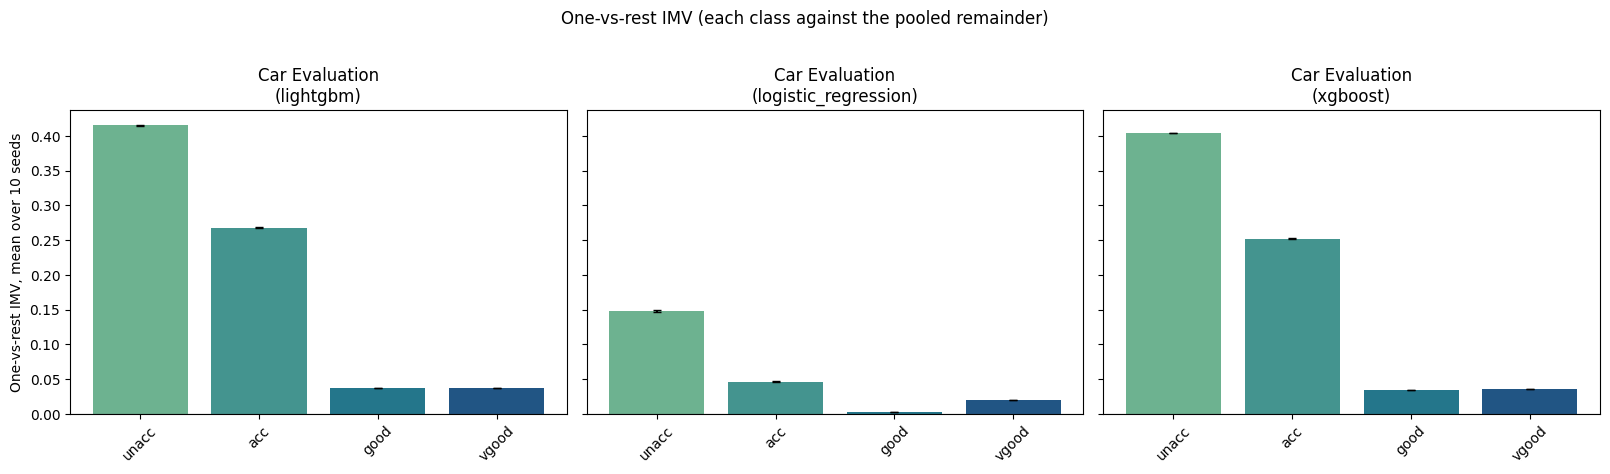

{'png': '../../../../CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/multi_imv_car_evaluation__one_vs_rest_imv.png',
 'pdf': '../../../../CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/multi_imv_car_evaluation__one_vs_rest_imv.pdf',
 'svg': '../../../../CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/multi_imv_car_evaluation__one_vs_rest_imv.svg'}

In [6]:
ova_summary = (ova.groupby(["model", "class"])["one_vs_rest_imv"]
               .agg(["mean", "std"]).reset_index())
models = list(ova_summary["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(5.4 * len(models), 4.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, models):
    part = ova_summary[ova_summary.model == name].sort_values("class")
    ax.bar([CLASS_NAMES[int(c)] for c in part["class"]], part["mean"],
           yerr=part["std"].fillna(0), capsize=3,
           color=sns.color_palette("crest", len(part)))
    ax.set_title(f"{TITLE}\n({name})")
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0, color="0.4", linewidth=0.8)
axes[0].set_ylabel(f"One-vs-rest IMV, mean over {len(SEEDS)} seeds")
fig.suptitle("One-vs-rest IMV (each class against the pooled remainder)", y=1.02)
fig.tight_layout()
paths = {file_format: relative_path(path, start=ARTIFACTS)
         for file_format, path in save_figure(
             fig, FIGURES / "multi_imv_car_evaluation__one_vs_rest_imv"
         ).items()}
plt.show()
paths

## 6. Pairwise figure

The pairwise matrix is **symmetric by construction** — `ll` is invariant under `(y,p) -> (1-y,1-p)` and pairwise renormalisation gives `p_j = 1 - p_i`. Unlike the ablation matrix it carries no directional information.

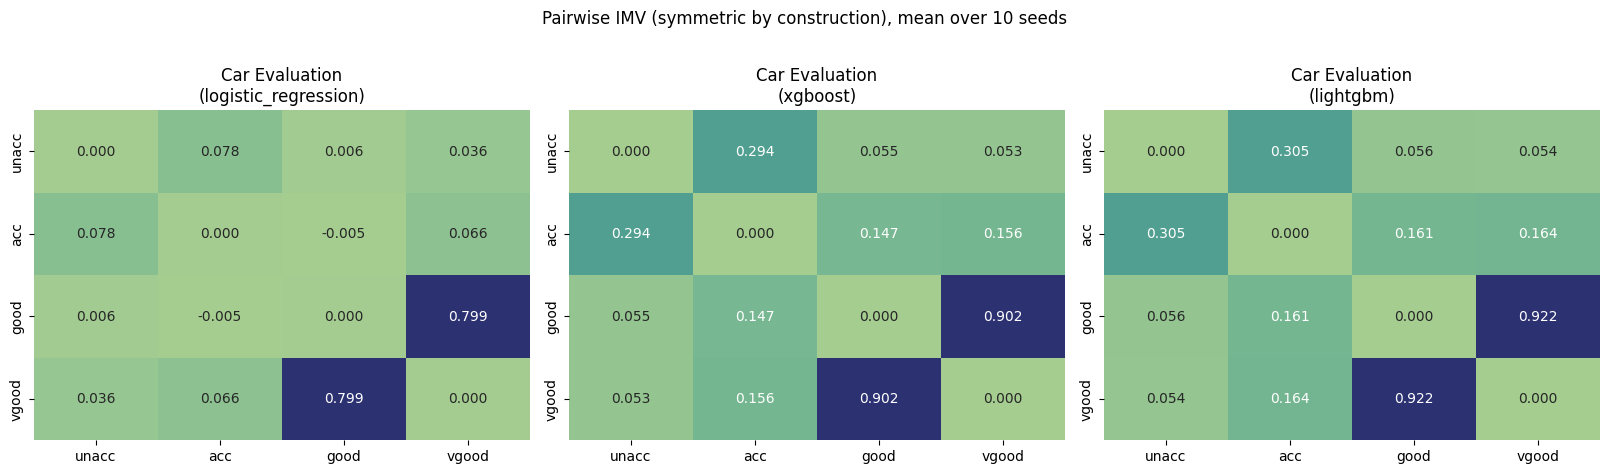

{'png': '../../../../CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/multi_imv_car_evaluation__pairwise_imv.png',
 'pdf': '../../../../CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/multi_imv_car_evaluation__pairwise_imv.pdf',
 'svg': '../../../../CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/multi_imv_car_evaluation__pairwise_imv.svg'}

In [7]:
fig, axes = plt.subplots(1, len(mean_matrices), figsize=(5.4 * len(mean_matrices), 4.6))
axes = np.atleast_1d(axes)
for ax, (name, matrix) in zip(axes, mean_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt=".3f", cmap="crest", cbar=False, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{TITLE}\n({name})")
fig.suptitle("Pairwise IMV (symmetric by construction), mean over "
             f"{len(SEEDS)} seeds", y=1.02)
fig.tight_layout()
paths = {file_format: relative_path(path, start=ARTIFACTS)
         for file_format, path in save_figure(
             fig, FIGURES / "multi_imv_car_evaluation__pairwise_imv"
         ).items()}
plt.show()
paths
